# Finite-Key vs. Asymptotic Length: How Much It Actually Matters

The finite-key-corrected secure output length is dramatically shorter than the naive
asymptotic formula — this notebook is where that ~99% reduction number comes from, plus a
comparison to QFabric's default `randextract`-based length heuristic (which isn't derived
from the finite-key security literature at all, and is worth knowing how far off it runs).

Run `20_data_cleaning_and_integrity.ipynb` first.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
from qne.cascade.finite_key import h, finite_key_output_length
from qne.cascade.validation_utils import wilson_ci, two_proportion_ztest

RESULTS = PROJECT_DIR / "results"
key_pairs_df = pd.read_csv(str(RESULTS / "key_pairs_metadata.csv"))
toeplitz_clean = pd.read_csv(str(RESULTS / "toeplitz_clean.csv"))
final_key_clean = pd.read_csv(str(RESULTS / "final_key_clean.csv"))
toeplitz_fk_clean = pd.read_csv(str(RESULTS / "toeplitz_fk_clean.csv"))
final_key_fk_clean = pd.read_csv(str(RESULTS / "final_key_fk_clean.csv"))

def asymptotic_key_length(n_bits, Q):
    return max(0, int(n_bits * (1 - 2 * h(Q))))


## The headline number: ell_finite / ell_asymptotic per key

In [2]:
print(f"{'key':<5} {'qber':<10} {'ell_asymptotic':<16} {'ell_finite':<12} {'ratio':<10}")
for key_idx in range(len(key_pairs_df)):
    row = key_pairs_df.iloc[key_idx]
    n_bits, k_pe, Q = int(row["n_bits"]), int(row["k_pe"]), float(row["qber"])
    ell_a = asymptotic_key_length(n_bits, Q)
    ell_fk, _, _, _ = finite_key_output_length(n_bits, k_pe, Q)
    ratio = ell_fk / ell_a if ell_a > 0 else float("nan")
    print(f"{key_idx:<5} {Q:<10.4f} {ell_a:<16} {ell_fk:<12.0f} {ratio:<10.4f}")


key   qber       ell_asymptotic   ell_finite   ratio     
0     0.0128     2810             23           0.0082    
1     0.0158     2608             1            0.0004    
2     0.0027     3180             337          0.1060    
3     0.0026     3251             363          0.1117    
4     0.0052     3131             269          0.0859    


## Comparison against QFabric's default length heuristic

`randextract`'s `ToeplitzHashing.calculate_length` is what QFabric uses by default -- it's a
generic extractor-length heuristic, not derived from the finite-key QKD security analysis.
Worth showing how far it diverges from the rigorous number.

In [3]:
from randextract import ToeplitzHashing

def placeholder_key_length(n_bits):
    return ToeplitzHashing.calculate_length(
        extractor_type="quantum", input_length=n_bits,
        relative_source_entropy=0.5, error_bound=1e-6,
    )

print(f"{'key':<5} {'ell_asymptotic':<16} {'ell_placeholder':<16} {'ell_finite':<12} {'reduction_%':<12}")
for key_idx in range(len(key_pairs_df)):
    row = key_pairs_df.iloc[key_idx]
    n_bits, k_pe, Q = int(row["n_bits"]), int(row["k_pe"]), float(row["qber"])
    ell_asymp = asymptotic_key_length(n_bits, Q)
    ell_place = placeholder_key_length(n_bits)
    ell_finite, _, _, _ = finite_key_output_length(n_bits, k_pe, Q)
    reduction = 100 * (1 - ell_finite / ell_asymp) if ell_asymp > 0 else float("nan")
    print(f"{key_idx:<5} {ell_asymp:<16} {ell_place:<16} {ell_finite:<12.0f} {reduction:<12.2f}")


key   ell_asymptotic   ell_placeholder  ell_finite   reduction_% 
0     2810             1714             23           99.18       
1     2608             1666             1            99.96       
2     3180             1642             337          89.40       
3     3251             1677             363          88.83       
4     3131             1690             269          91.41       


## Does the mismatch rate actually drop under finite_key mode, as it should?

In [4]:
print("=== Toeplitz: finite_key vs asymptotic mismatch rate, per key/probability ===")
for key_idx in sorted(toeplitz_fk_clean["key_index"].unique()):
    asymp_all = toeplitz_clean[toeplitz_clean["key_index"] == key_idx]
    fk_all = toeplitz_fk_clean[toeplitz_fk_clean["key_index"] == key_idx]
    for prob in sorted(fk_all["prob"].unique()):
        asymp_g, fk_g = asymp_all[asymp_all["prob"] == prob], fk_all[fk_all["prob"] == prob]
        if len(asymp_g) == 0 or len(fk_g) == 0:
            continue
        s1, n1 = asymp_g["mismatch"].sum(), len(asymp_g)
        s2, n2 = fk_g["mismatch"].sum(), len(fk_g)
        z, p = two_proportion_ztest(s1, n1, s2, n2)
        direction = "LOWER (as predicted)" if s2/n2 < s1/n1 else "NOT lower"
        sig = "**" if p < 0.05 else ""
        print(f"  key{key_idx} prob={prob:<6}: asymptotic={s1/n1:.2f}, finite_key={s2/n2:.2f}, "
              f"p={p:.4f} {sig} [{direction}]")


=== Toeplitz: finite_key vs asymptotic mismatch rate, per key/probability ===
  key0 prob=0.001 : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key0 prob=0.003 : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key0 prob=0.01  : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key0 prob=0.03  : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key0 prob=0.05  : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key0 prob=0.1   : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key0 prob=0.3   : asymptotic=0.20, finite_key=0.10, p=0.5312  [LOWER (as predicted)]
  key0 prob=0.5   : asymptotic=0.20, finite_key=0.10, p=0.5312  [LOWER (as predicted)]
  key1 prob=0.001 : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key1 prob=0.003 : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key1 prob=0.01  : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key1 prob=0.03  : asymptotic=0.00, finite_key=0.00, p=nan  [NOT lower]
  key1 prob=0.05  

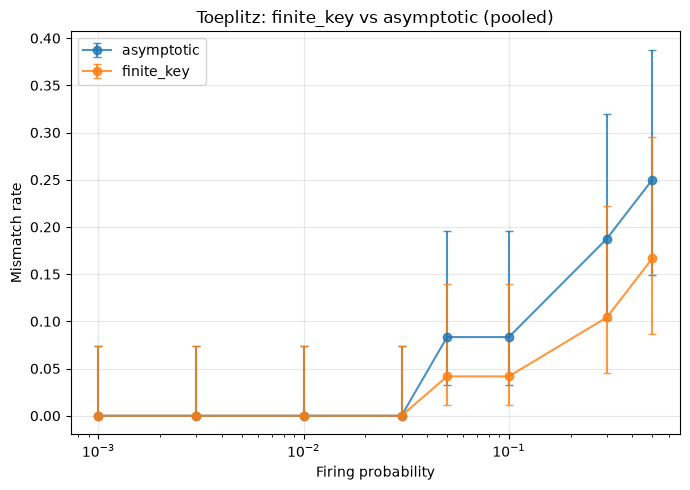

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for mode_df, mode_name, color in [(toeplitz_clean, "asymptotic", "tab:blue"), (toeplitz_fk_clean, "finite_key", "tab:orange")]:
    probs = sorted(mode_df["prob"].unique())
    obs, los, his = [], [], []
    for prob in probs:
        sub = mode_df[mode_df["prob"] == prob]
        p_hat, lo, hi = wilson_ci(sub["mismatch"].sum(), len(sub))
        obs.append(p_hat); los.append(lo); his.append(hi)
    obs, los, his = np.array(obs), np.array(los), np.array(his)
    ax.errorbar(probs, obs, yerr=[np.clip(obs-los,0,None), np.clip(his-obs,0,None)],
                  fmt="o-", capsize=3, color=color, label=mode_name, alpha=0.8)
ax.set_xscale("log"); ax.set_xlabel("Firing probability"); ax.set_ylabel("Mismatch rate")
ax.set_title("Toeplitz: finite_key vs asymptotic (pooled)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTS / "fig_finitekey_vs_asymptotic.png"), dpi=150)
plt.show()


In [3]:
from qne.cascade.finite_key import optimize_nu

key1 = key_pairs_df.iloc[1]
n_bits, k_pe, qber = int(key1["n_bits"]), int(key1["k_pe"]), float(key1["qber"])
print(f"key1: n_bits={n_bits}, k_pe={k_pe}, qber={qber:.4f}")

nu, eps_actual, r, _ = optimize_nu(n_bits, k_pe, qber, eps_ec=1e-10, eps_pa=1e-10, c_bar=0.5)
print(f"nu={nu:.5f}, r (cascade leakage)={r:.1f}, Q+nu={qber+nu:.4f}")
print(f"h(Q+nu)={h(qber+nu):.5f}  <- if this is close to 1, the length formula collapses toward 0")

ell, r_check, t, nu_check = finite_key_output_length(n_bits, k_pe, qber)
print(f"ell={ell}, t={t}")
print(f"\nCompare against key0 (not an outlier) for reference:")
key0 = key_pairs_df.iloc[0]
n0, k0, q0 = int(key0["n_bits"]), int(key0["k_pe"]), float(key0["qber"])
nu0, _, r0, _ = optimize_nu(n0, k0, q0, eps_ec=1e-10, eps_pa=1e-10, c_bar=0.5)
print(f"key0: nu={nu0:.5f}, h(Q+nu)={h(q0+nu0):.5f}")

key1: n_bits=3409, k_pe=379, qber=0.0158
nu=0.26465, r (cascade leakage)=494.7, Q+nu=0.2805
h(Q+nu)=0.85610  <- if this is close to 1, the length formula collapses toward 0
ell=1, t=11.735132884139947

Compare against key0 (not an outlier) for reference:
key0: nu=0.26087, h(Q+nu)=0.84670
